# Dependencies

In [15]:
from prepare_time_boroughs import prepare_yearly_boroughs, prepare_quarterly_boroughs, prepare_monthly_boroughs
from forecasting_class import Forecast
import pandas as pd
import matplotlib.pyplot as plt
import geopandas
import geopandas as gpd

from pathlib import Path
ROOT = Path('/Users/josh/Library/CloudStorage/GoogleDrive-jeverer@gmail.com/My Drive/London Sport/london_sport2')
list(ROOT.rglob('*.shp'))

[PosixPath('/Users/josh/Library/CloudStorage/GoogleDrive-jeverer@gmail.com/My Drive/London Sport/london_sport2/src/stream_1/forecasting/borough_amplitude.shp')]

In [16]:
df_year = prepare_yearly_boroughs()
df_quarter = prepare_quarterly_boroughs()
df_month = prepare_monthly_boroughs()

PREPARING YEARLY DATA...
COMPLETE
PREPARING QUARTERLY DATA...
COMPLETE
PREPARING MONTHLY DATA...
COMPLETE


# Seasonality Analysis

In [17]:
smb = Forecast(df_month, forecast_steps=, group_col='LA_Name')
smb.sarima()
smb.get_mae('sarima')
smb.plot()

SyntaxError: invalid syntax (1247092830.py, line 1)

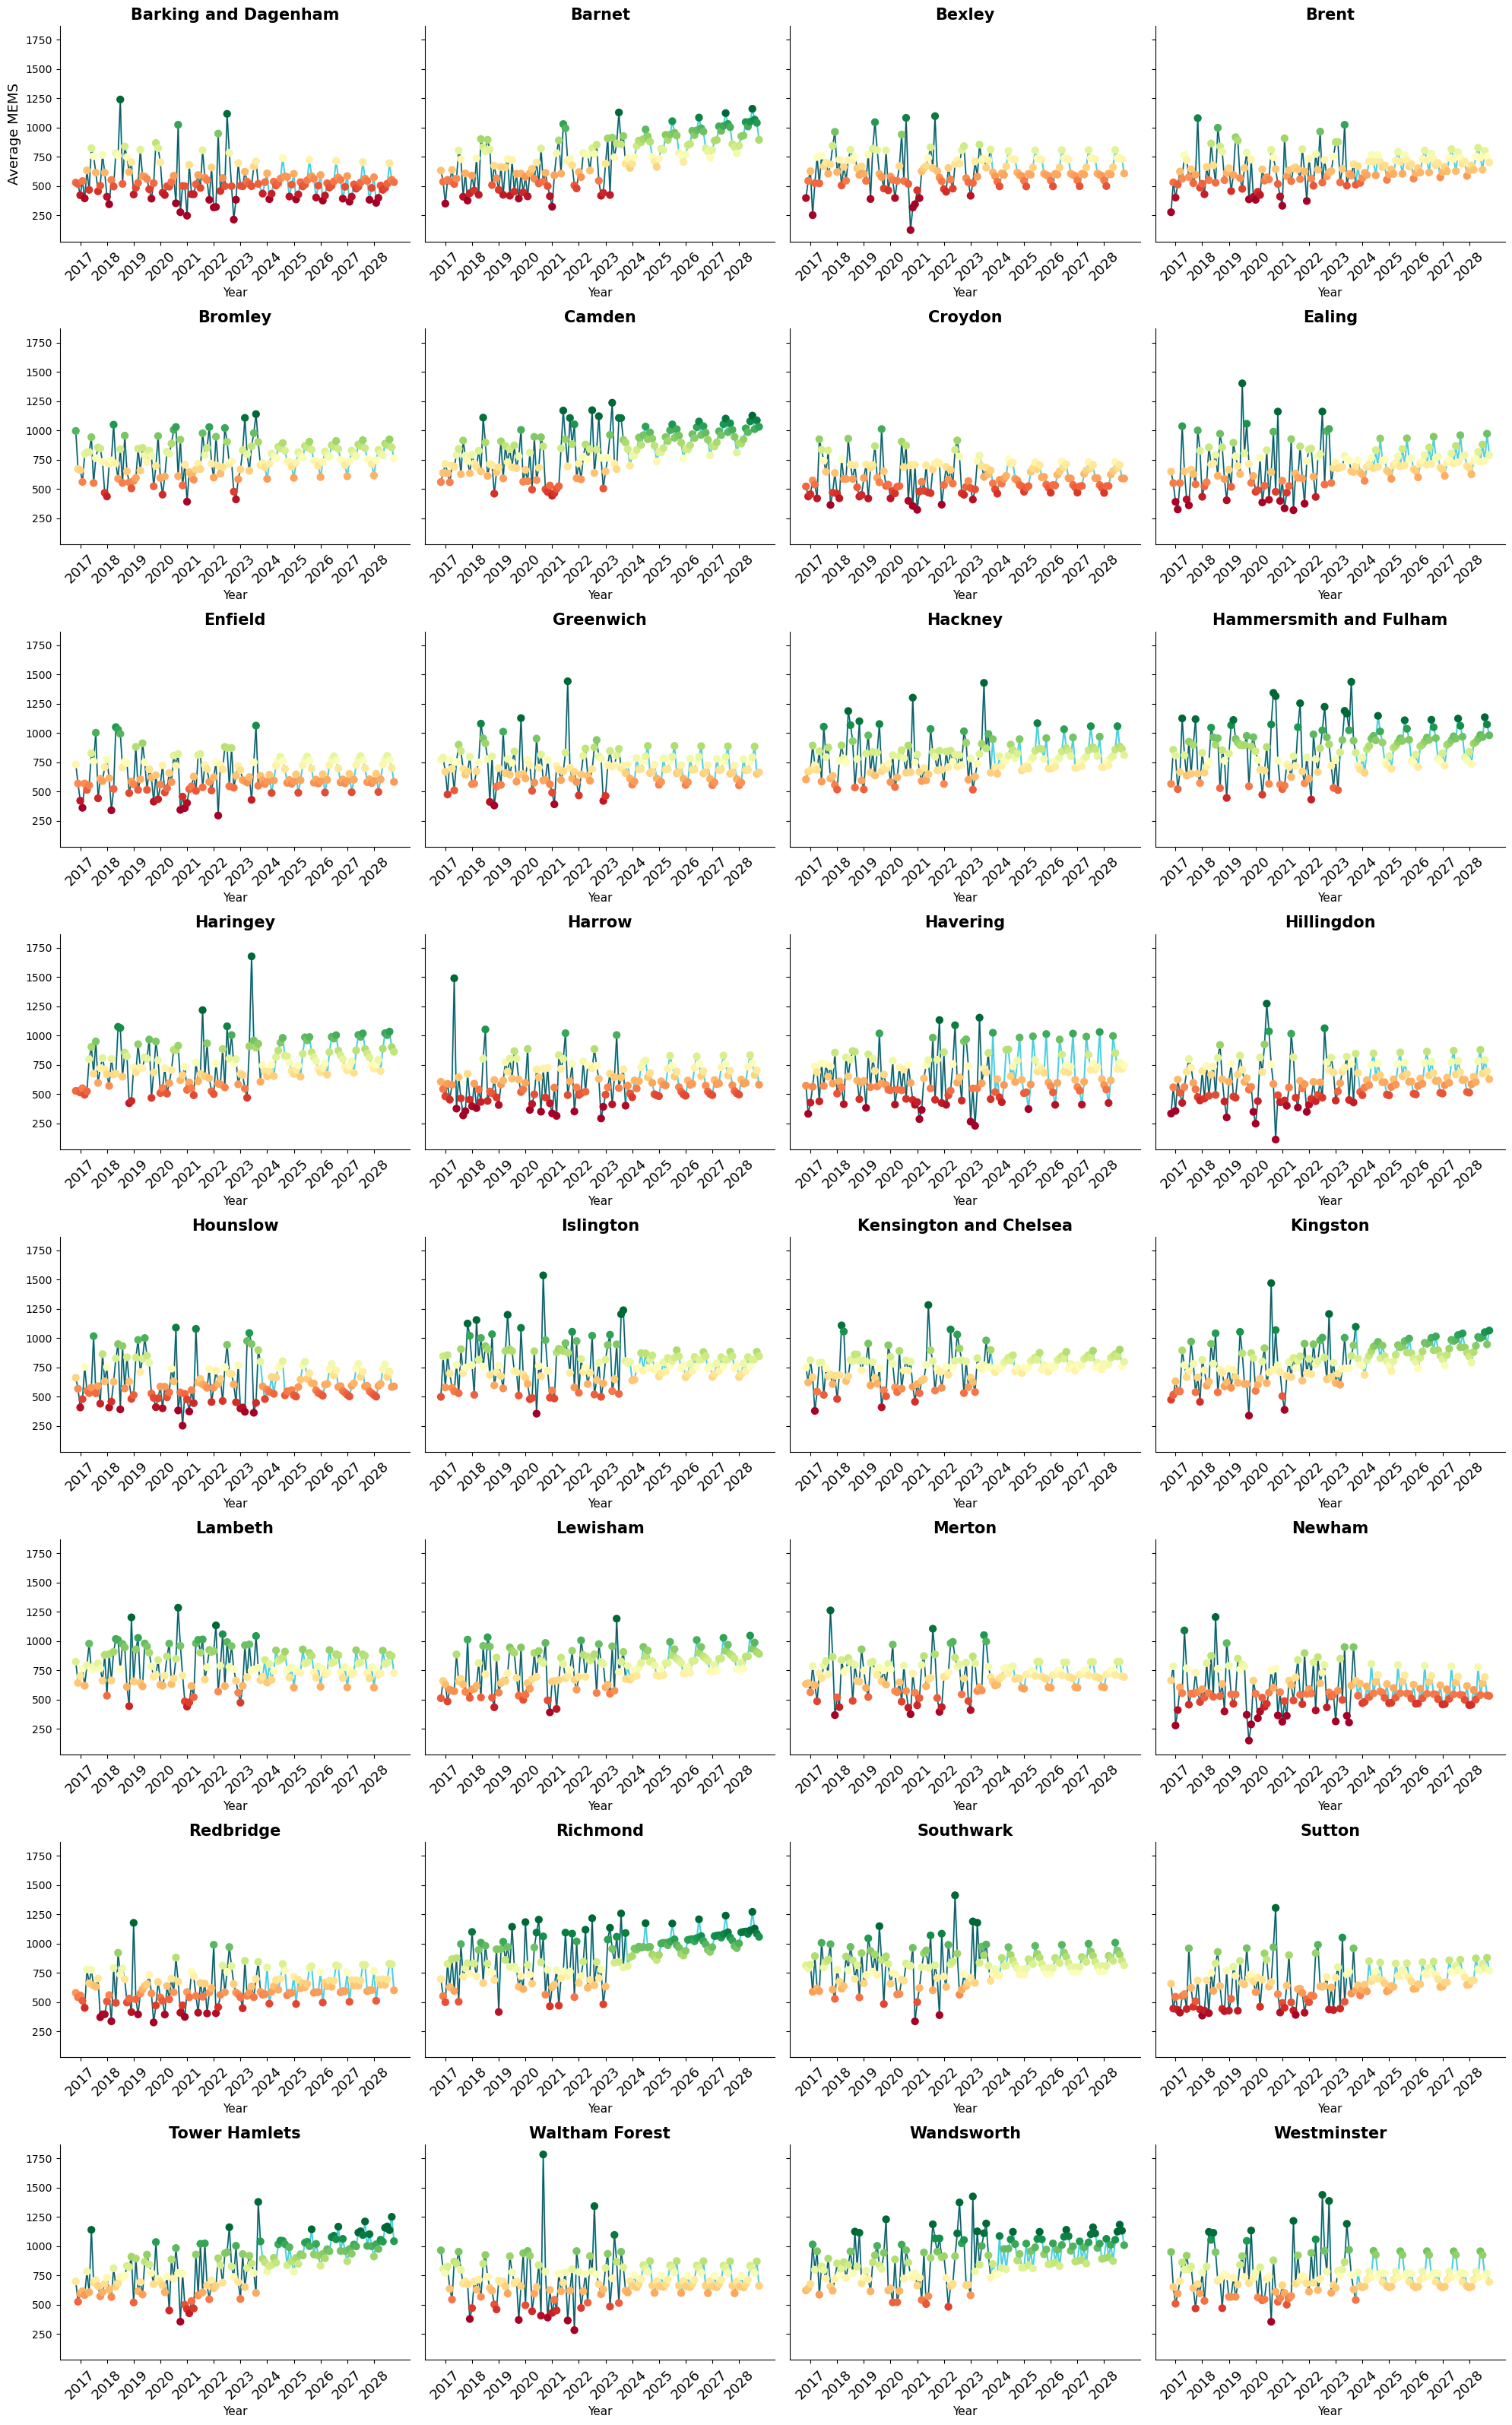

In [ ]:
smb = Forecast(df_month, forecast_steps=60, group_col='LA_Name')
smb.sarima()
smb.get_mae('sarima')
smb.plot()

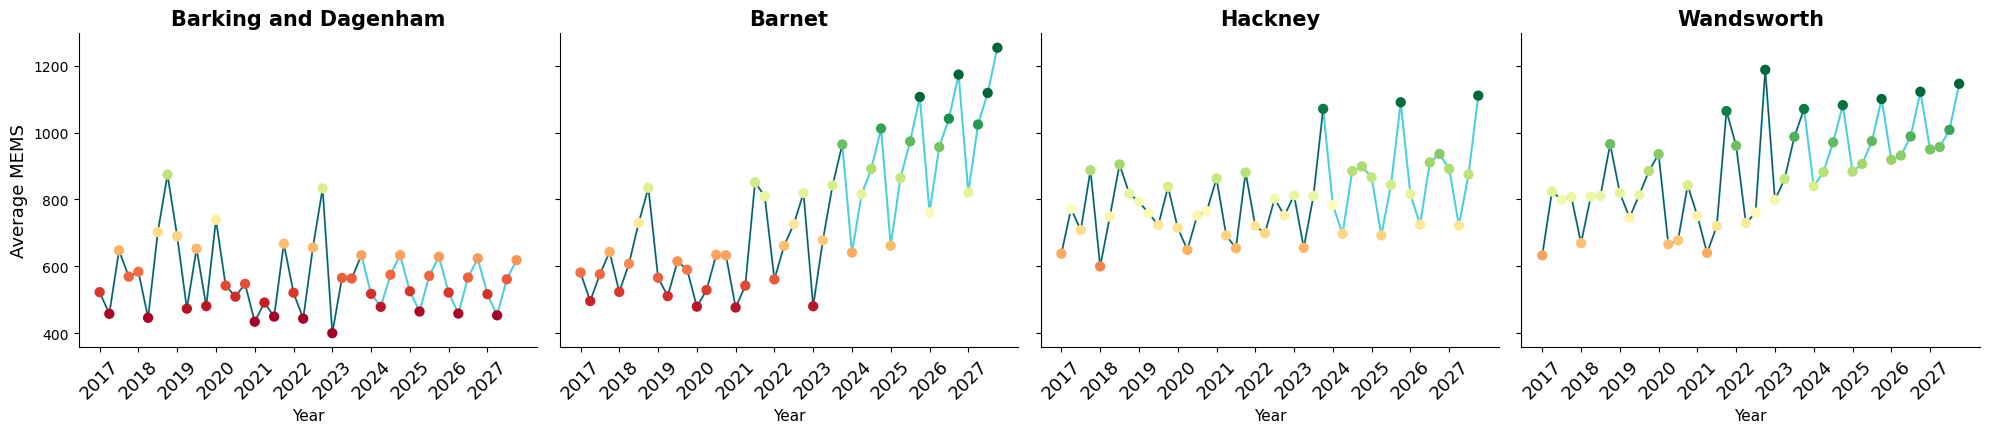

In [ ]:
sqb = Forecast(df_quarter, forecast_steps=16, group_col='LA_Name')
sqb.sarima()
sqb.get_mae('sarima')
sqb.plot(show=['Barking and Dagenham', 'Barnet', 'Hackney', 'Wandsworth'])
#print('\n')
#sqb.plot()

# Amplitude Analysis

In [ ]:
url = "https://raw.githubusercontent.com/radoi90/housequest-data/master/london_boroughs.geojson"
gdf = gpd.read_file(url)
print(gdf.columns.tolist())

['name', 'color', 'geometry']


In [ ]:
summer = df_month[df_month['month'].isin([6,7,8])].groupby('LA_Name')['MEMS7_ALL'].mean()
winter = df_month[df_month['month'].isin([12,1,2])].groupby('LA_Name')['MEMS7_ALL'].mean()
amplitude = (summer - winter).reset_index()
amplitude.columns = ['LA_Name', 'amplitude']

amplitude['LA_Name'] = amplitude['LA_Name'].replace({
    'Kingston': 'Kingston upon Thames',
    'Richmond': 'Richmond upon Thames'
})

gdf_merged = gdf.merge(amplitude, left_on='name', right_on='LA_Name', how='left')

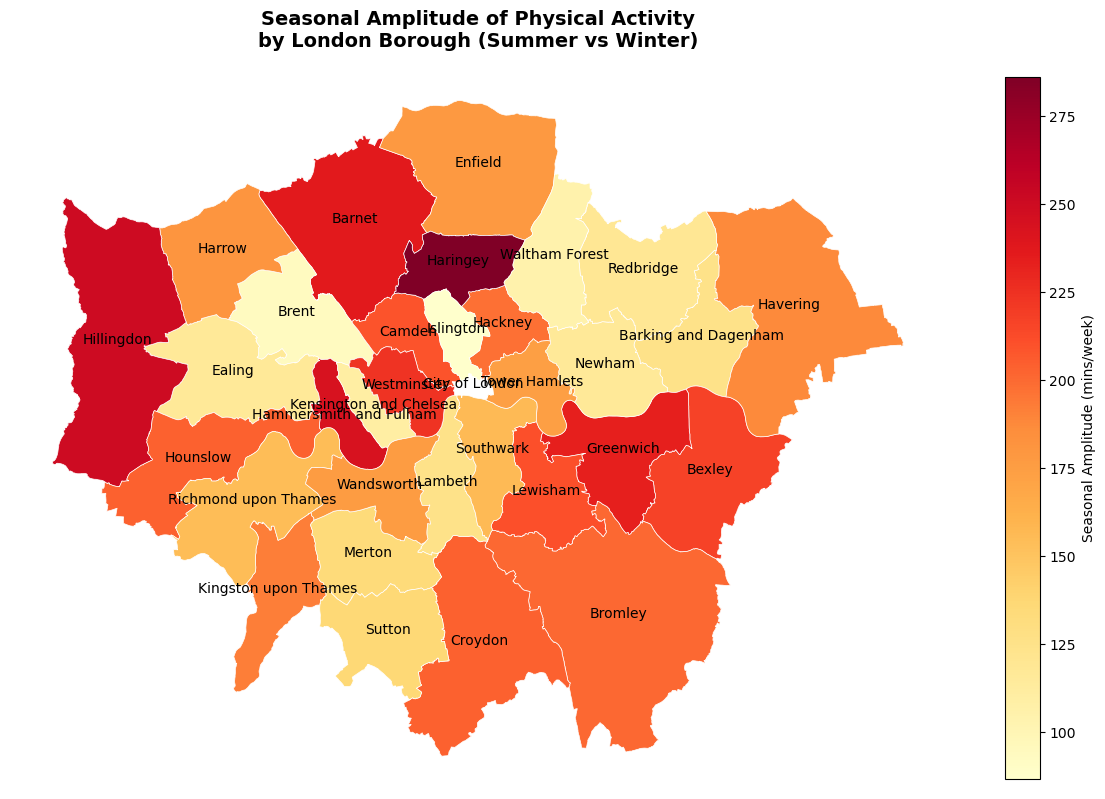

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib import cm

fig, ax = plt.subplots(figsize=(12, 12))

gdf_merged.plot(
    column='amplitude',
    ax=ax,
    cmap='YlOrRd',
    legend=True,
    legend_kwds={'label': 'Seasonal Amplitude (mins/week)', 'shrink': 0.6},
    edgecolor='white',
    linewidth=0.5
)

for _, row in gdf_merged.iterrows():
    ax.annotate(
        row['name'],
        xy=(row.geometry.centroid.x, row.geometry.centroid.y),
        ha='center', fontsize=10, color='black'
    )

ax.set_title('Seasonal Amplitude of Physical Activity\nby London Borough (Summer vs Winter)', 
             fontsize=14, fontweight='bold', pad=15)
ax.axis('off')
plt.tight_layout()
plt.savefig('choropleth_amplitude.png', dpi=150, bbox_inches='tight')
plt.show()

gdf_merged[['name', 'amplitude']].to_csv('borough_amplitude.csv', index=False)
gdf_merged.to_file('borough_amplitude.shp')

In [ ]:
borough_maes = sqb.sarima_forecast[['LA_Name', 'mae']].sort_values('mae')

best_3 = borough_maes.head(3)['LA_Name'].tolist()
worst_3 = borough_maes.tail(3)['LA_Name'].tolist()
print("Best:", best_3)
print("Worst:", worst_3)

Best: ['Barking and Dagenham', 'Bromley', 'Islington']
Worst: ['Kingston', 'Haringey', 'Hillingdon']


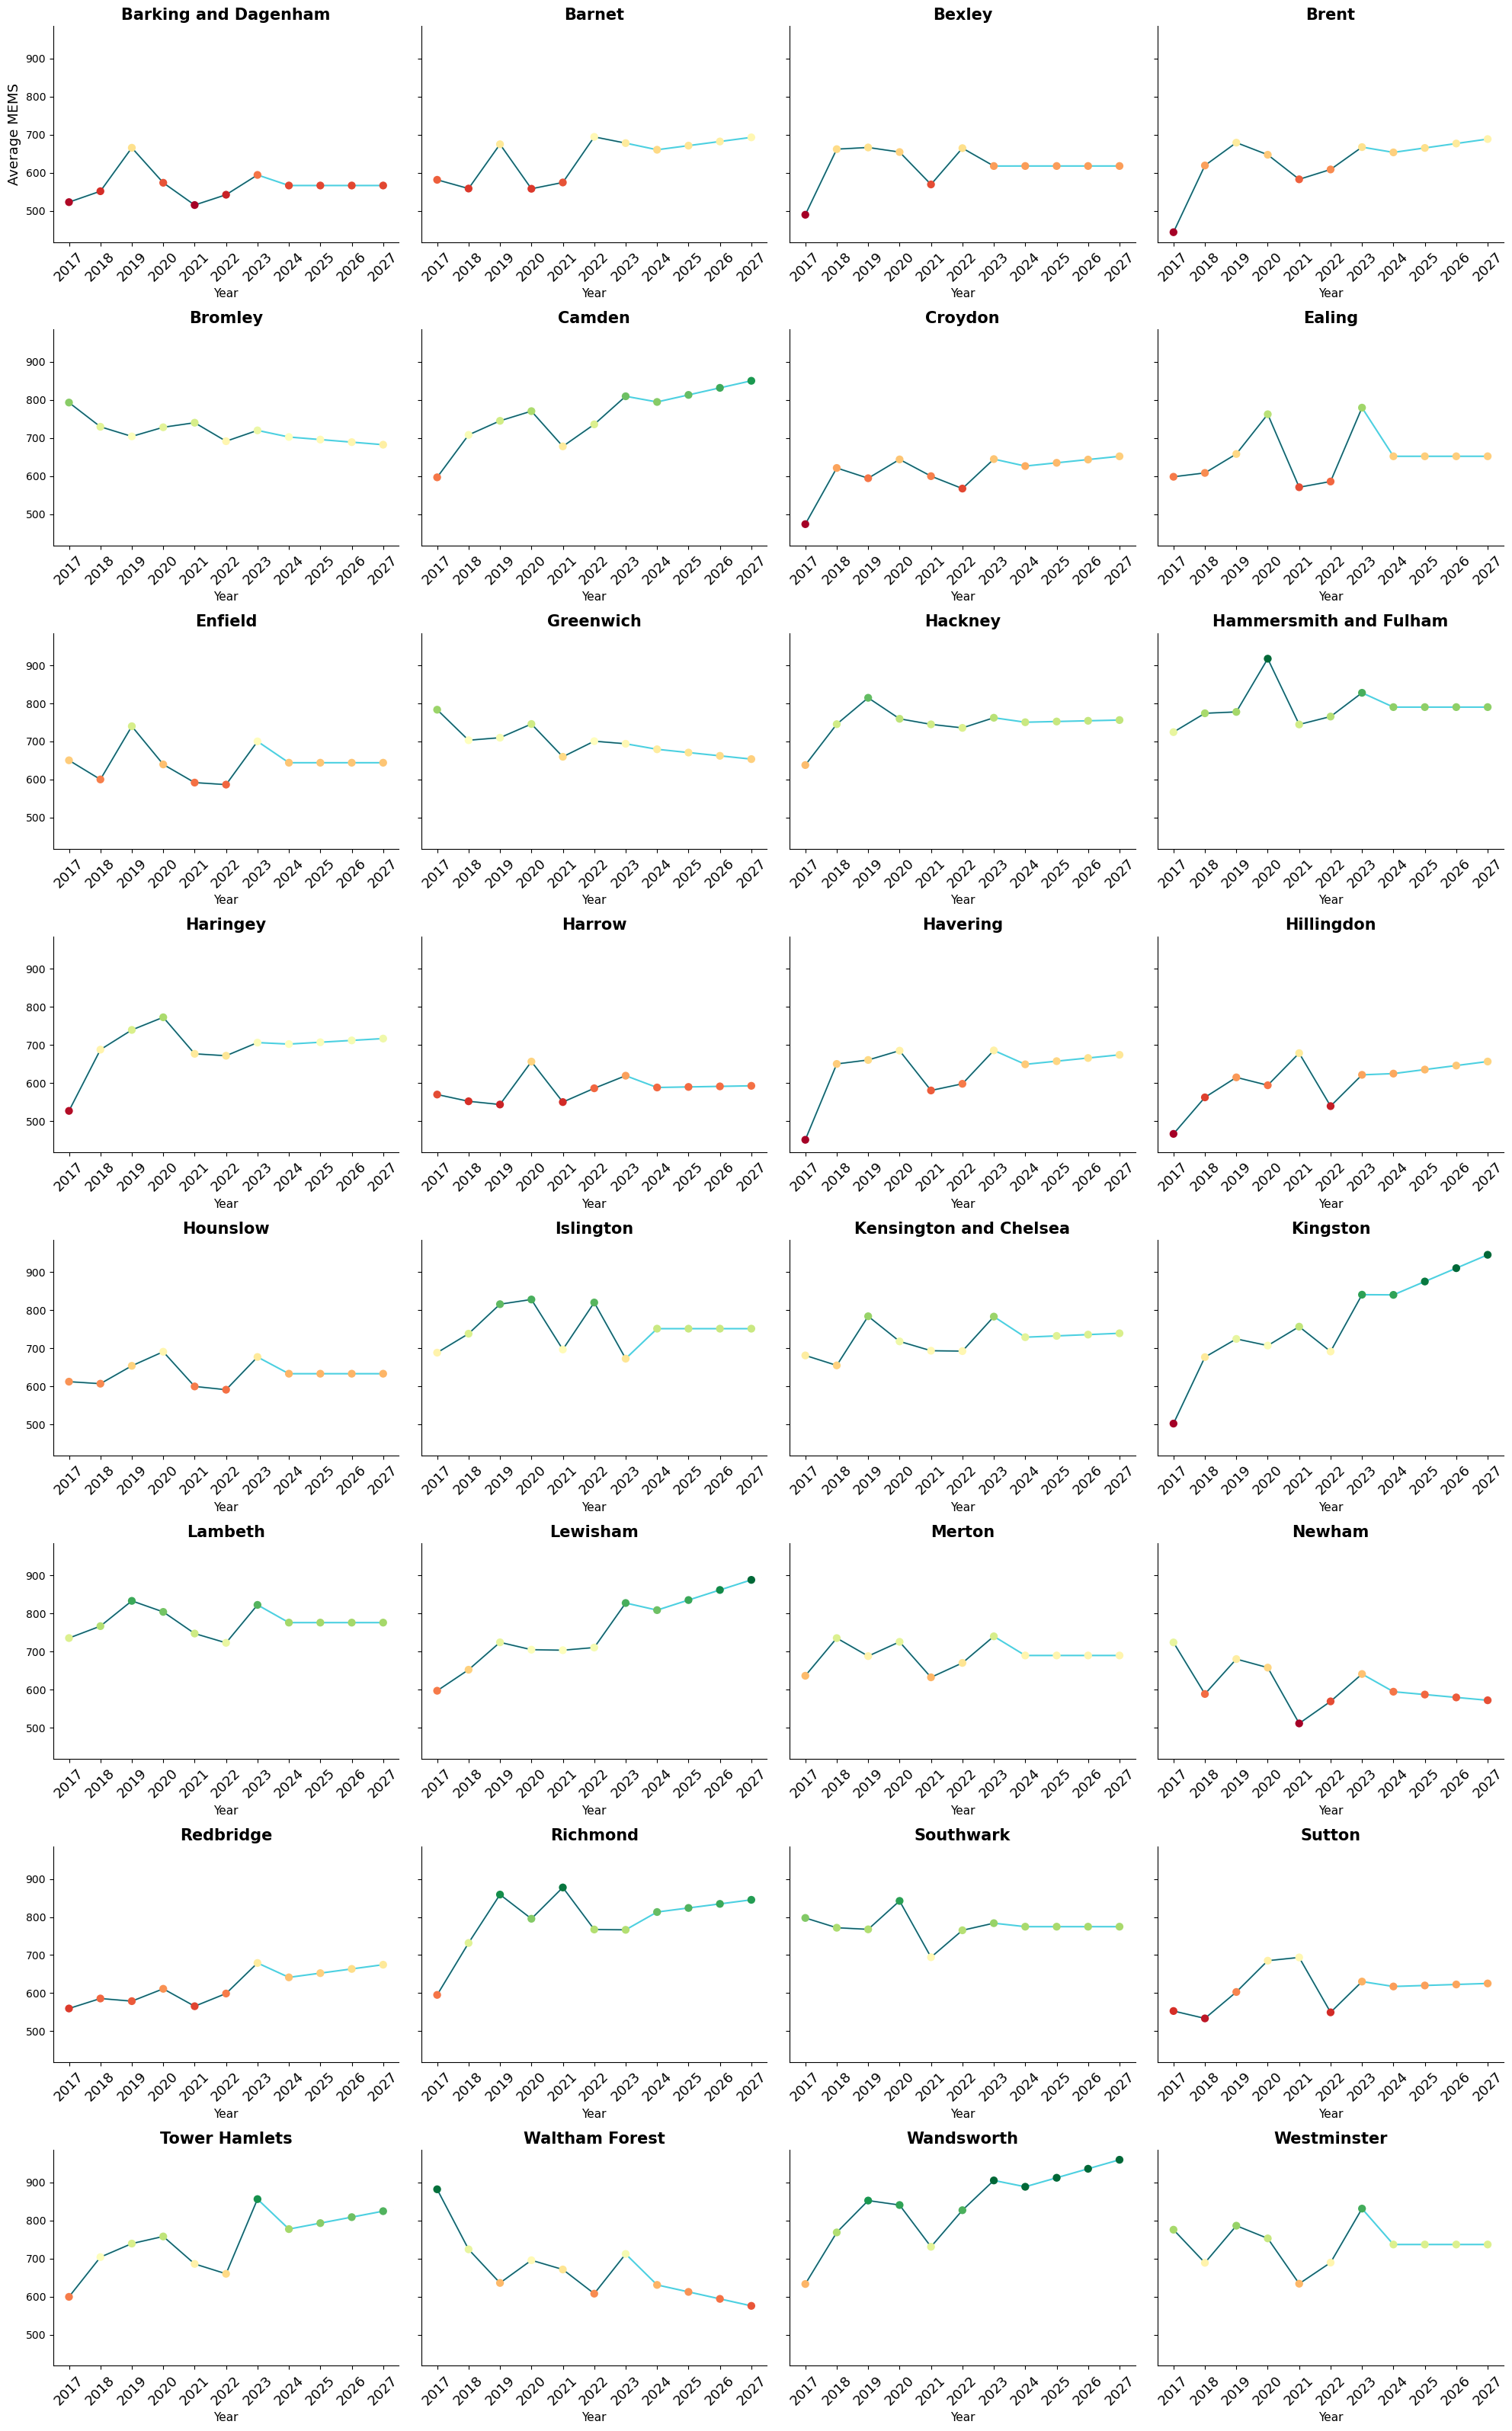

In [ ]:
tab_year = Forecast(df_year, forecast_steps=4, group_col='LA_Name')
tab_year.bayesian_ridge()
tab_year.get_mae('bayesian_ridge')
tab_year.plot('bayesian_ridge')

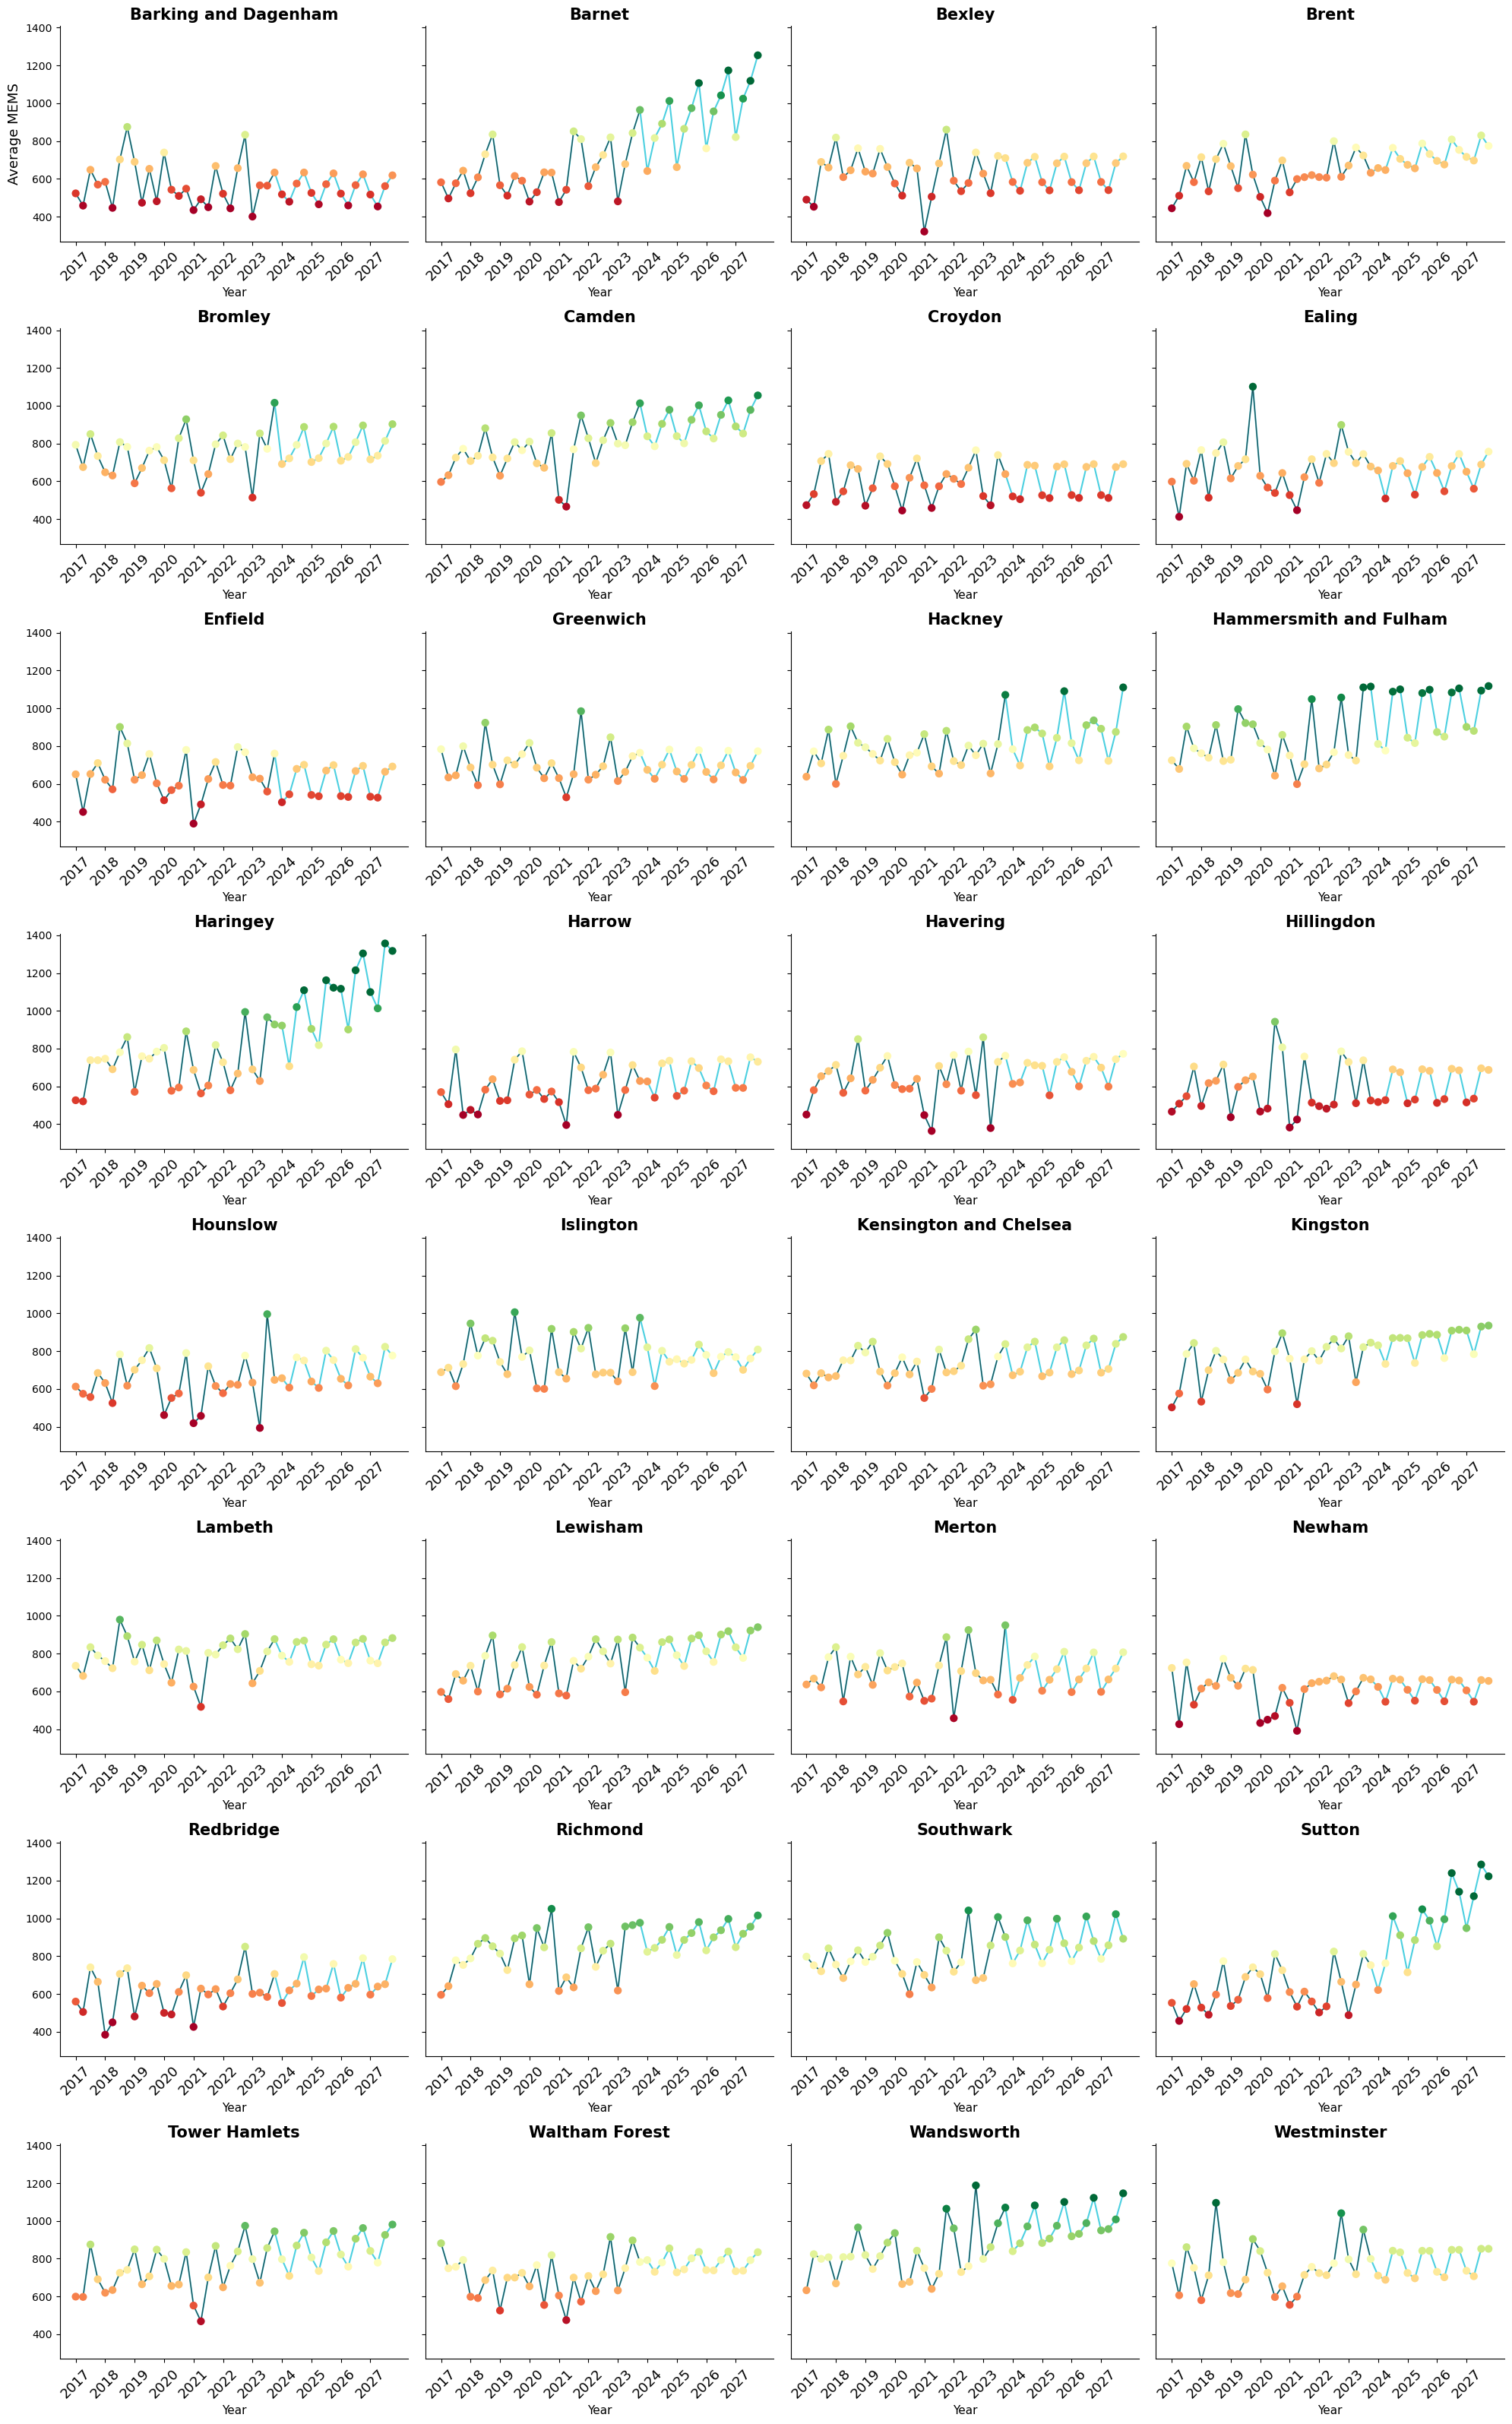

In [ ]:
tab_quarter = Forecast(df_quarter, forecast_steps=16, group_col='LA_Name')
tab_quarter.sarima()
tab_quarter.get_mae('sarima')
tab_quarter.plot('sarima')

In [ ]:
rows = []
for _, row in tab_year.bayesian_ridge_forecast.iterrows():
    y_train = list(row['y_train'])
    y_forecast = list(row['y_forecast'])
    for t, actual in enumerate(y_train):
        rows.append({'LA_Name': row['LA_Name'], 't': t, 'MEMS_actual': actual, 'MEMS_bayesian': None, 'period': 'train'})
    rows.append({'LA_Name': row['LA_Name'], 't': len(y_train), 'MEMS_actual': y_train[-1], 'MEMS_bayesian': y_forecast[0], 'period': 'forecast'})
    for t, forecast in enumerate(y_forecast[1:], start=len(y_train)+1):
        rows.append({'LA_Name': row['LA_Name'], 't': t, 'MEMS_bayesian': forecast, 'MEMS_actual': None, 'period': 'forecast'})
pd.DataFrame(rows).to_csv('tableau_borough_yearly.csv', index=False)

In [ ]:
rows = []
for _, row in tab_quarter.sarima_forecast.iterrows():
    for t, (actual, forecast) in enumerate(zip(row['y_train'], [None]*len(row['y_train']))):
        rows.append({'LA_Name': row['LA_Name'], 't': t, 'MEMS_actual': actual, 'MEMS_sarima': None, 'period': 'train'})
    rows.append({'LA_Name': row['LA_Name'], 't': len(list(row['y_train'])), 'MEMS_actual': list(row['y_train'])[-1], 'MEMS_sarima': list(row['y_forecast'])[0], 'period': 'forecast'})
    for t, forecast in enumerate(row['y_forecast'][1:], start=len(row['y_train'])+1):
        rows.append({'LA_Name': row['LA_Name'], 't': t, 'MEMS_sarima': forecast, 'MEMS_actual': None, 'period': 'forecast'})

pd.DataFrame(rows).to_csv('tableau_borough_quarterly.csv', index=False)